**Neural networks for road segmentation**
========================

Your next task is to train neural network to segment road on images from car cams.

The original dataset is provided by Karlsruhe Institute of Technology (http://www.cvlibs.net/datasets/kitti/eval_road.php). Their images are ±370x1270, but, for simlictiy, we will use 370x370 squares.

One can download the dataset from https://disk.yandex.ru/d/QPOw4hk84-se_w

Here is an example of input data with corresponding ground truth:

In [1]:
import os
import cv2
import numpy as np

import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image


import torchvision.models as models
import torch
import torch.nn as nn
import torch.nn.functional as F

import random
import torchvision.transforms.functional as ttf
from torchvision.transforms import InterpolationMode

from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm


import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def get_paths(path):
    _, _, filenames = next(os.walk(path))

    images_paths = []
    for filename in sorted(filenames):
        images_paths.append(os.path.join(path, filename))

    return np.stack(images_paths)


class RoadDataset(Dataset):
    """Feel free to rewrite it. For ex. cache all images in RAM to increase training speed"""

    def __init__(
        self,
        images,
        masks,
        image_transform,
        mask_transform,
        aug=None,
    ):
        self.images = sorted(images)
        self.masks = sorted(masks)
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.aug = aug

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        im_name = self.images[idx]
        mask_name = self.masks[idx]

        image = cv2.imread(im_name)[
            :, :, ::-1
        ]  # / 255.0  # ::-1 to convert from BGR to RGB
        mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        image = Image.fromarray(image)
        mask = Image.fromarray(mask)

        if self.aug:
            sample = self.aug(
                image=image,
                mask=mask,
            )
        else:
            sample = {
                "image": image,
                "mask": mask,
            }

        sample["image"] = self.image_transform(sample["image"]).float()
        sample["mask"] = self.mask_transform(sample["mask"]).float()

        return sample

In [3]:
class SegAugments:
    def __call__(self, image, mask):
        if random.random() < 0.5:
            image = ttf.hflip(image)
            mask = ttf.hflip(mask)

        if random.random() < 0.5:
            image = ttf.vflip(image)
            mask = ttf.vflip(mask)

        if random.random() < 0.3:
            angle = random.uniform(-10, 10)
            image = ttf.rotate(
                image,
                angle,
                interpolation=InterpolationMode.BILINEAR,
                expand=False,
                fill=0,
            )
            mask = ttf.rotate(
                mask,
                angle,
                interpolation=InterpolationMode.NEAREST,
                expand=False,
                fill=0,
            )

        if random.random() < 0.5:
            image = ttf.adjust_brightness(image, random.uniform(0.7, 1.3))
        if random.random() < 0.5:
            image = ttf.adjust_contrast(image, random.uniform(0.7, 1.3))

        return {"image": image, "mask": mask}

In [4]:
X_train = get_paths("data/train/images")
y_train = get_paths("data/train/gt")


X_test = get_paths("data/test/images")
y_test = get_paths("data/test/gt")

image_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)
mask_transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

train_dataset = RoadDataset(
    X_train, y_train, image_transform, mask_transform, aug=SegAugments()
)
test_dataset = RoadDataset(X_test, y_test, image_transform, mask_transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


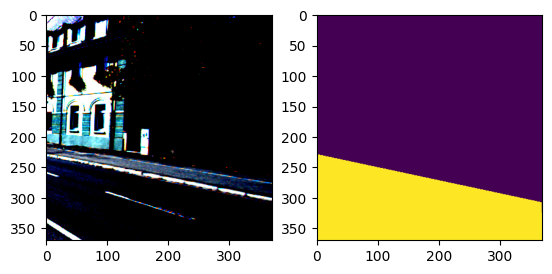

In [5]:
sample = train_dataset[110]
image = sample["image"]
mask = sample["mask"]

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))
plt.show()

Workflow:
---
* Choose correct loss function, write training loop and code for testing. Feel free to use previous HW for inspiration. 
* Train any segmentation neural network from scratch (for example U-Net) and achieve >= 0.75 IoU on test set (40% points). See function to calculate the metric below.
* Use any pretrained model for image classification, convert it for segmentation by adding decoder (don't forget skip-connections) or usign dilated convolutions and achieve >= 0.87 IoU  on test set (60% points).

You're not allowed to do only one thing: train your network on test set.

----
Your final solution will consist of an ipython notebook with code (for final networks training + any experiments with data) and test metric calculation.

Feel free to ask in Telegram chat if something is not clear :3


In [6]:
print(f"Dataset length {len(train_dataset)}")

Dataset length 648


Dataset is small so actively use data augmentation: rotations, flip, color-change etc. to prevent overfitting.

Most likely you'll have to pad your images to 512x512 (it divides by 2^5=32, like U-Net wants). Use PadIfNeeded from Albumentations and central crop (see below) after prediction to calculate loss/metrics (you don't want to pay attention on padded values).

----
There is a hard data class imbalance in dataset, so the network output will be biased toward "zero" class. You can either tune the minimal probability threshold for the "road" class, or add class weights in optimized loss. You also can try to use softIoU or DICE loss.

Good luck!

In [7]:
def calc_iou(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += (
            np.logical_and(prediction[i] > 0, ground_truth[i] > 0)
            .astype(np.float32)
            .sum()
        )
        union += (
            np.logical_or(prediction[i] > 0, ground_truth[i] > 0)
            .astype(np.float32)
            .sum()
        )
    return float(intersection) / union

In [8]:
def central_crop(images, size):
    current_size = images.size(2)
    border_len = (current_size - size) // 2
    images = images[
        :,
        :,
        border_len : current_size - border_len,
        border_len : current_size - border_len,
    ]

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, last_relu=True):
        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True) if last_relu else nn.Identity(),
        )

    def forward(self, x):
        x = self.conv(x)
        return x


class Up(nn.Module):
    def __init__(self, in1, in2, out, scale_factor=2, last_relu=True):
        super(Up, self).__init__()

        self.up = nn.Upsample(
            scale_factor=scale_factor, mode="bilinear", align_corners=True
        )
        self.conv = DoubleConv(in1 + in2, out, last_relu=last_relu)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, (diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2))
        x = torch.cat([x2, x1], dim=1)

        x = self.conv(x)
        return x

In [10]:
import itertools


class ResNetDecoder(nn.Module):
    def __init__(self, pretrained: bool = False):
        super().__init__()

        resnet = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        )

        self.down1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.down2 = nn.Sequential(resnet.maxpool, resnet.layer1)
        self.down3 = resnet.layer2
        self.down4 = resnet.layer3
        self.down5 = resnet.layer4

        self.up1 = Up(2048, 1024, 1024, 2)
        self.up2 = Up(1024, 512, 512, 2)
        self.up3 = Up(512, 256, 256, 2)
        self.up4 = Up(256, 64, 64, 2)
        self.up5 = Up(64, 3, 1, 2, last_relu=False)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(x1)
        x3 = self.down3(x2)
        x4 = self.down4(x3)
        x5 = self.down5(x4)

        result = self.up1(x5, x4)
        result = self.up2(result, x3)
        result = self.up3(result, x2)
        result = self.up4(result, x1)
        result = self.up5(result, x)
        result = torch.sigmoid(result)
        return result

    def encoder_parameters(self):
        return itertools.chain(
            self.down1.parameters(),
            self.down2.parameters(),
            self.down3.parameters(),
            self.down4.parameters(),
            self.down5.parameters(),
        )

    def decoder_parameters(self):
        return itertools.chain(
            self.up1.parameters(),
            self.up2.parameters(),
            self.up3.parameters(),
            self.up4.parameters(),
            self.up5.parameters(),
        )

In [11]:
def loss_fn(outputs, targets):
    dice = (
        2
        * (targets * outputs).sum([1, 2, 3])
        / (targets.sum([1, 2, 3]) + outputs.sum([1, 2, 3]) + 1e-8)
    )

    return (
        torch.nn.BCELoss()(outputs.reshape(-1, 1), targets.reshape(-1, 1))
        + (1 - dice).mean()
    )

In [12]:
assert torch.cuda.is_available()
device = torch.device("cuda:0")

In [13]:
writer = SummaryWriter(log_dir="runs/from_scratch")

BATCH_SIZE = 10
tran_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = ResNetDecoder(pretrained=False).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS = 70
global_step = 0

for ep in tqdm(range(NUM_EPOCHS)):
    model.train()
    for batch in tran_dataloader:
        batch_X = batch["image"].to(device)
        batch_y = batch["mask"].to(device)

        result = model(batch_X)
        loss = loss_fn(result, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        writer.add_scalar("loss/train", loss.item(), global_step)

        global_step += 1

    model.eval()
    test_losses = []

    test_result = []
    test_target = []
    for batch in test_dataloader:
        batch_X = batch["image"].to(device)
        batch_y = batch["mask"].to(device)

        with torch.no_grad():
            result = model(batch_X)

            test_result.append(result.cpu())
            test_target.append(batch_y.cpu())

            loss = loss_fn(result, batch_y)

        test_losses.append(loss.item())

    writer.add_scalar("loss/test", sum(test_losses) / len(test_losses), global_step)

    test_result = torch.cat(test_result, dim=0).numpy()
    test_target = torch.cat(test_target, dim=0).numpy()

    iou = calc_iou(test_result > 0.5, test_target)
    writer.add_scalar("iou/test", iou, global_step)

    if iou >= 0.75:
        print("Threshold reached")
        break


print("Final test IOU:", iou)

  0%|          | 0/70 [00:00<?, ?it/s]

Threshold reached
Final test IOU: 0.7585157387952794


In [14]:
writer = SummaryWriter(log_dir="runs/pretrained")

BATCH_SIZE = 10
tran_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = ResNetDecoder(pretrained=True).to(device)
optimizer = torch.optim.Adam(
    [
        {"params": model.encoder_parameters(), "lr": 1e-5},
        {"params": model.decoder_parameters(), "lr": 1e-4},
    ]
)

NUM_EPOCHS = 70
global_step = 0

for ep in tqdm(range(NUM_EPOCHS)):
    model.train()
    for batch in tran_dataloader:
        batch_X = batch["image"].to(device)
        batch_y = batch["mask"].to(device)

        result = model(batch_X)
        loss = loss_fn(result, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        writer.add_scalar("loss/train", loss.item(), global_step)

        global_step += 1

    model.eval()
    test_losses = []

    test_result = []
    test_target = []
    for batch in test_dataloader:
        batch_X = batch["image"].to(device)
        batch_y = batch["mask"].to(device)

        with torch.no_grad():
            result = model(batch_X)

            test_result.append(result.cpu())
            test_target.append(batch_y.cpu())

            loss = loss_fn(result, batch_y)

        test_losses.append(loss.item())

    writer.add_scalar("loss/test", sum(test_losses) / len(test_losses), global_step)

    test_result = torch.cat(test_result, dim=0).numpy()
    test_target = torch.cat(test_target, dim=0).numpy()

    iou = calc_iou(test_result > 0.5, test_target)
    writer.add_scalar("iou/test", iou, global_step)

    if iou >= 0.87:
        print("Threshold reached")
        break


print("Final test IOU:", iou)

  0%|          | 0/70 [00:00<?, ?it/s]

Threshold reached
Final test IOU: 0.8715570551935637


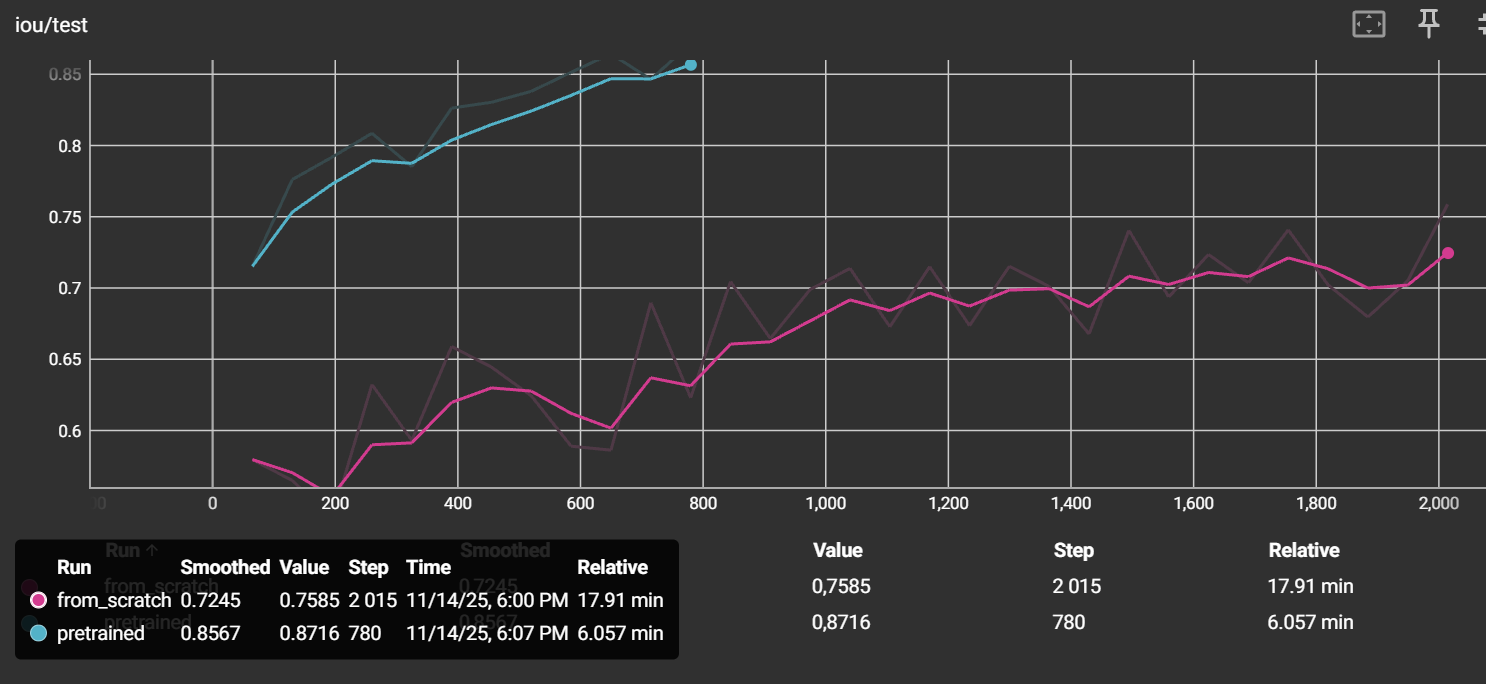

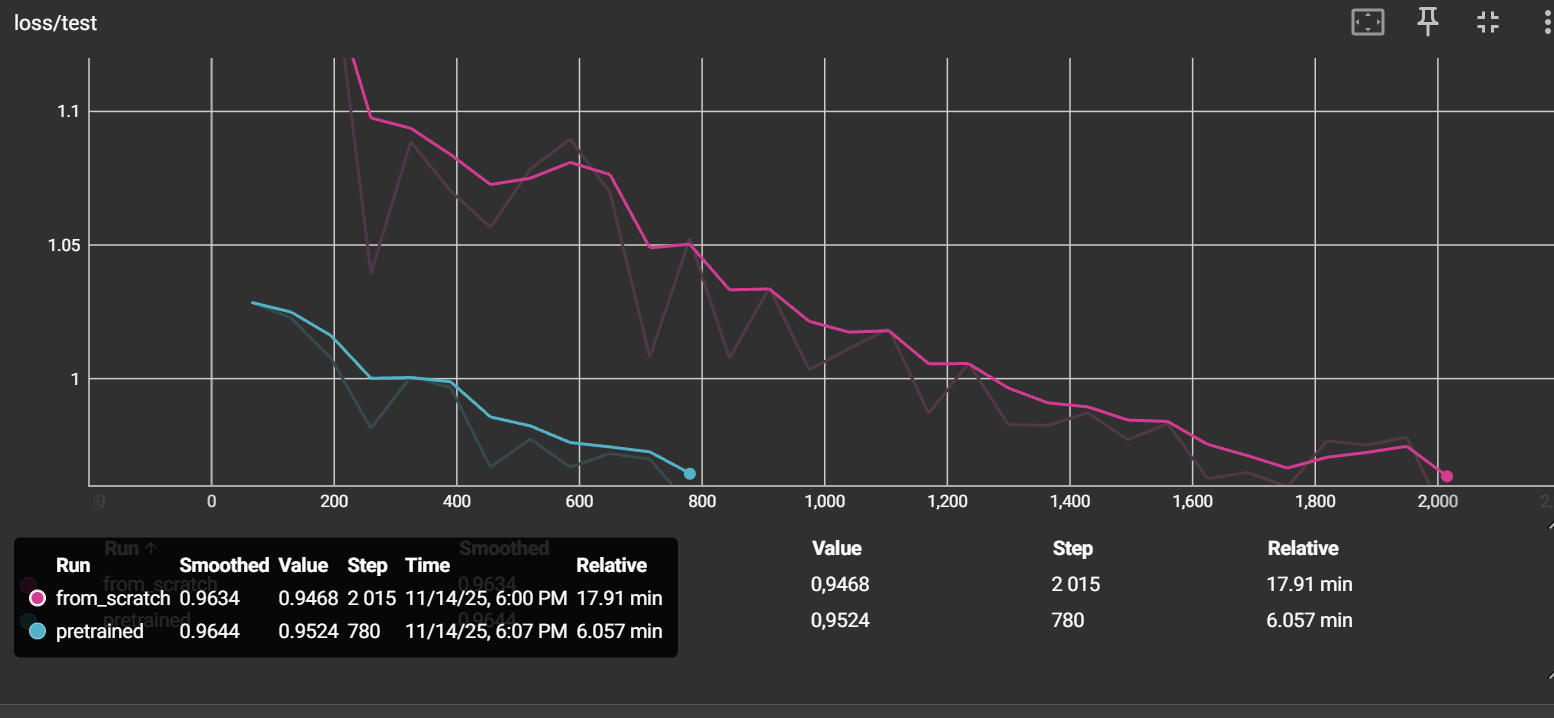